<a href="https://colab.research.google.com/github/arpitdhote51/DL/blob/main/Alexnet-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten,Dense , Activation, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

#Normalise pixel values
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:
model = Sequential()
#layer 1
model.add(Conv2D(96 , kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#layer 2
model.add(Conv2D(256 , kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#layer 3
model.add(Conv2D(384 , kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))

#layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))

#layer 5
model.add(Conv2D(256 , kernel_size=(3,3), strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#flatten
model.add(Flatten())

#fuly connected layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

#output layer
model.add(Dense(10))
model.add(Activation('softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [5]:
history = model.fit(x_train,y_train, batch_size=128, epochs=15 , validation_split=0.2,
                    verbose=1)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.4336 - loss: 1.6226 - val_accuracy: 0.0980 - val_loss: 6.8847
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.5985 - loss: 1.1294 - val_accuracy: 0.6164 - val_loss: 1.0574
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.6867 - loss: 0.8887 - val_accuracy: 0.4758 - val_loss: 2.3163
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.7408 - loss: 0.7459 - val_accuracy: 0.7293 - val_loss: 0.7954
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7838 - loss: 0.6202 - val_accuracy: 0.7474 - val_loss: 0.7780
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8194 - loss: 0.5225 - val_accuracy: 0.7776 - val_loss: 0.6730
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8522 - loss: 0.4275 - val_accuracy: 0.7657 - val_loss: 0.7575
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8788 - loss: 0.3460 - 

In [6]:
test_loss,test_acc = model.evaluate(x_test,y_test)
print(test_loss,test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7944 - loss: 0.9239
0.923876166343689 0.7943999767303467


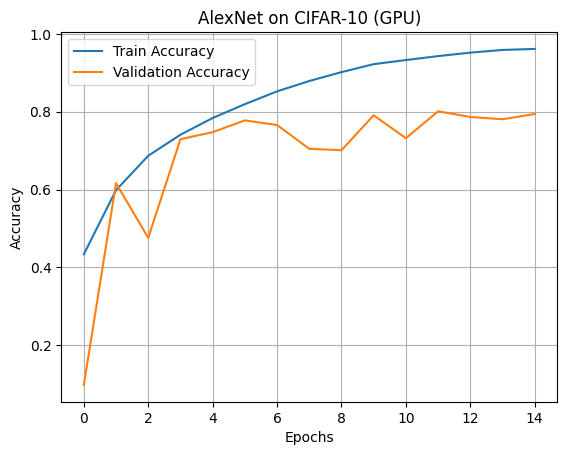

In [7]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (GPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()